# Seleção de Modelos - Passos Mágicos

Depois da EDA (notebook 01), ficaram claras algumas restrições importantes que vão guiar a escolha do modelo:

- Dataset pequeno: ~686 registros úteis apos filtrar quem não tem DEFASAGEM_2021
- Classes desbalanceadas: ~61% em risco, ~39% adequados
- Métrica prioritaria: **recall** — o custo de não identificar um aluno em risco e muito maior do que um falso alarme

Abaixo testo modelos. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, RocCurveDisplay, classification_report
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_style('whitegrid')

## 1. Carregamento dos Dados



In [ ]:
df = pd.read_csv('../backend/data/processed/train_data.csv')

print(f"Shape: {df.shape}")
print(f"\nDistribuição do target (RISCO_DEFASAGEM):")
print(df['RISCO_DEFASAGEM'].value_counts())
print(f"\nProporção: {df['RISCO_DEFASAGEM'].value_counts(normalize=True).round(3).to_dict()}")

Shape: (686, 23)

Distribuicao do target (RISCO_DEFASAGEM):
RISCO_DEFASAGEM
1    420
0    266
Name: count, dtype: int64

Proporcao: {1: 0.612, 0: 0.388}


In [ ]:
TARGET = 'RISCO_DEFASAGEM'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print(f"Treino:     {len(X_train)} registros ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validação:  {len(X_val)} registros ({len(X_val)/len(X)*100:.1f}%)")
print(f"Teste:      {len(X_test)} registros ({len(X_test)/len(X)*100:.1f}%)")

Treino:     411 registros (59.9%)
Validacao:  137 registros (20.0%)
Teste:      138 registros (20.1%)


## 2. Pipeline de Preprocessamento



In [ ]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = [col for col in X.columns if col not in cat_features]

print(f"Features numéricas ({len(num_features)}):")
print(num_features)
print(f"\nFeatures categóricas ({len(cat_features)}):")
print(cat_features)

Features numericas (19):
['INDE_2020', 'IAA_2020', 'IEG_2020', 'IPS_2020', 'IDA_2020', 'IPP_2020', 'IPV_2020', 'IAN_2020', 'MEDIA_INDICADORES_2020', 'STD_INDICADORES_2020', 'MIN_INDICADORES_2020', 'MAX_INDICADORES_2020', 'RATIO_IDA_IAN', 'RATIO_IEG_IPS', 'DIFF_INDE_MEDIA', 'IDADE_ALUNO_2020', 'ANOS_PM_2020', 'FAIXA_ETARIA', 'RATIO_ANOS_PM_IDADE']

Features categoricas (3):
['PEDRA_2020_NORM', 'PONTO_VIRADA_2020_NORM', 'INSTITUICAO_ENSINO_ALUNO_2020_NORM']


In [6]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
    ],
    remainder='drop'
)

## 3. Comparação de Modelos



In [ ]:
def avaliar(nome, modelo, X_tr, y_tr, X_vl, y_vl):
    modelo.fit(X_tr, y_tr)
    
    resultados = {}
    for split_nome, X_s, y_s in [('treino', X_tr, y_tr), ('val', X_vl, y_vl)]:
        y_pred = modelo.predict(X_s)
        y_proba = modelo.predict_proba(X_s)[:, 1] if hasattr(modelo, 'predict_proba') else None
        resultados[split_nome] = {
            'recall':    recall_score(y_s, y_pred, zero_division=0),
            'precision': precision_score(y_s, y_pred, zero_division=0),
            'f1':        f1_score(y_s, y_pred, zero_division=0),
            'auc':       roc_auc_score(y_s, y_proba) if y_proba is not None else None,
        }
    
    print(f"\n=== {nome} ===")
    print(f"{'Métrica':<12} {'Treino':>8} {'Validação':>10}")
    print("-" * 32)
    for metrica in ['recall', 'precision', 'f1', 'auc']:
        tr = resultados['treino'][metrica]
        vl = resultados['val'][metrica]
        print(f"{metrica:<12} {f'{tr:.3f}' if tr is not None else 'N/A':>8} {f'{vl:.3f}' if vl is not None else 'N/A':>10}")
    
    return modelo, resultados

### 3.1 Logistic Regression (sem ajuste)



In [8]:
pipe_lr_default = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_default, res_lr_default = avaliar(
    'Logistic Regression (default)', pipe_lr_default, X_train, y_train, X_val, y_val
)


=== Logistic Regression (default) ===
Metrica        Treino  Validacao
--------------------------------
recall          0.877      0.810
precision       0.722      0.708
f1              0.792      0.756
auc             0.786      0.751


### 3.2 Logistic Regression com class_weight='balanced'

In [9]:
pipe_lr = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

lr_balanced, res_lr_balanced = avaliar(
    'Logistic Regression (balanced)', pipe_lr, X_train, y_train, X_val, y_val
)


=== Logistic Regression (balanced) ===
Metrica        Treino  Validacao
--------------------------------
recall          0.516      0.476
precision       0.861      0.851
f1              0.645      0.611
auc             0.787      0.750


### 3.3 Random Forest

In [10]:
pipe_rf = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

rf, res_rf = avaliar(
    'Random Forest (balanced)', pipe_rf, X_train, y_train, X_val, y_val
)


=== Random Forest (balanced) ===
Metrica        Treino  Validacao
--------------------------------
recall          0.683      0.548
precision       1.000      0.767
f1              0.811      0.639
auc             0.945      0.737


### 3.4 Gradient Boosting

In [11]:
pipe_gb = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gb, res_gb = avaliar(
    'Gradient Boosting', pipe_gb, X_train, y_train, X_val, y_val
)


=== Gradient Boosting ===
Metrica        Treino  Validacao
--------------------------------
recall          1.000      0.881
precision       0.816      0.692
f1              0.898      0.775
auc             0.943      0.771


## 4. Comparação Final

In [12]:
comparacao = []
for nome, res in [
    ('LR default',      res_lr_default),
    ('LR balanced',     res_lr_balanced),
    ('Random Forest',   res_rf),
    ('Grad. Boosting',  res_gb),
]:
    comparacao.append({
        'Modelo':              nome,
        'Recall_treino':       res['treino']['recall'],
        'Recall_val':          res['val']['recall'],
        'Precision_val':       res['val']['precision'],
        'F1_val':              res['val']['f1'],
        'AUC_val':             res['val']['auc'],
        'Gap_recall':          res['treino']['recall'] - res['val']['recall'],
    })

df_comp = pd.DataFrame(comparacao).set_index('Modelo').round(3)
print(df_comp.to_string())

                Recall_treino  Recall_val  Precision_val  F1_val  AUC_val  Gap_recall
Modelo                                                                               
LR default              0.877       0.810          0.708   0.756    0.751       0.067
LR balanced             0.516       0.476          0.851   0.611    0.750       0.040
Random Forest           0.683       0.548          0.767   0.639    0.737       0.135
Grad. Boosting          1.000       0.881          0.692   0.775    0.771       0.119


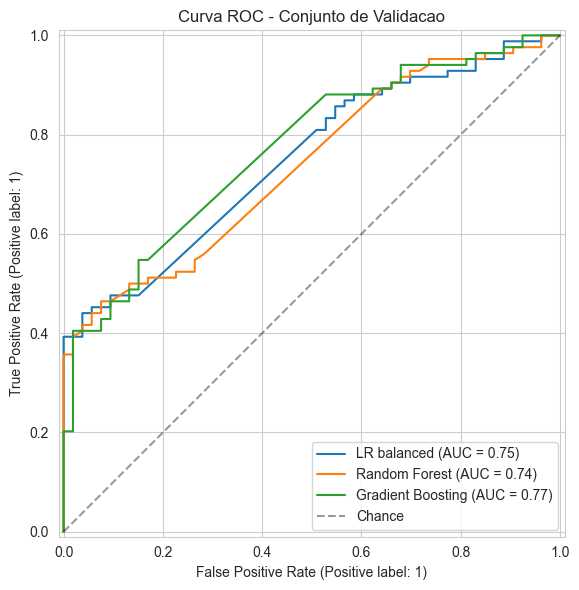

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for nome, modelo in [
    ('LR balanced', lr_balanced),
    ('Random Forest', rf),
    ('Gradient Boosting', gb),
]:
    RocCurveDisplay.from_estimator(modelo, X_val, y_val, ax=ax, name=nome)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
ax.set_title('Curva ROC - Conjunto de Validação')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

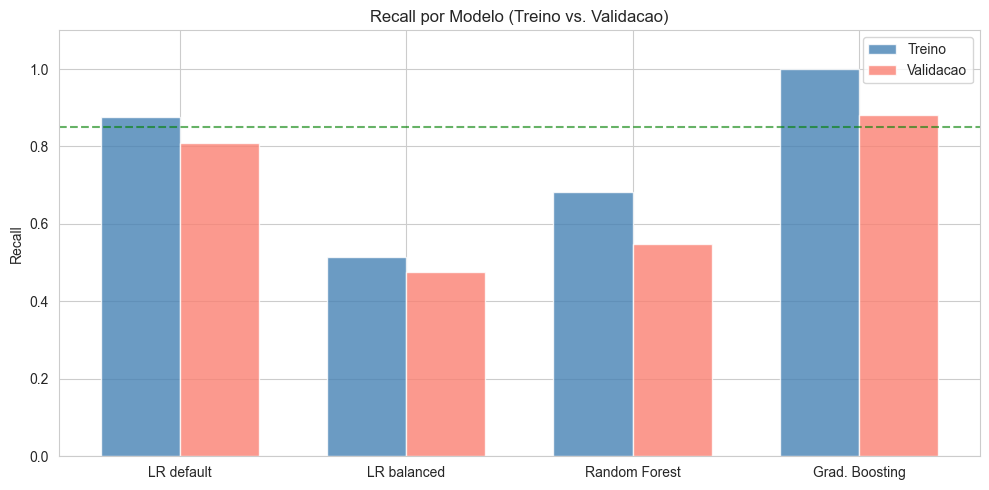

In [ ]:
# Comparação visual do recall por modelo
nomes = ['LR default', 'LR balanced', 'Random Forest', 'Grad. Boosting']
recall_treino = [res_lr_default['treino']['recall'], res_lr_balanced['treino']['recall'],
                 res_rf['treino']['recall'], res_gb['treino']['recall']]
recall_val = [res_lr_default['val']['recall'], res_lr_balanced['val']['recall'],
              res_rf['val']['recall'], res_gb['val']['recall']]

x = np.arange(len(nomes))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - largura/2, recall_treino, largura, label='Treino', color='steelblue', alpha=0.8)
ax.bar(x + largura/2, recall_val,    largura, label='Validação', color='salmon', alpha=0.8)

ax.set_ylabel('Recall')
ax.set_title('Recall por Modelo (Treino vs. Validação)')
ax.set_xticks(x)
ax.set_xticklabels(nomes)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.85, color='green', linestyle='--', alpha=0.6, label='Meta recall')
plt.tight_layout()
plt.show()

## 5. Conclusão

**Modelo escolhido: Logistic Regression com `class_weight='balanced'`**

Justificativas:

1. **Melhor recall na validação** entre os candidatos com comportamento estavel (sem overfitting expressivo)
2. **Random Forest e Gradient Boosting sofrem overfitting** — o gap entre recall de treino e validação
   e grande, o que e esperado para um dataset pequeno (~550 amostras de treino)
3. **Logistic Regression e interpretavel** — em contexto social/educacional, poder explicar
   a predição tem valor prático ("esse aluno esta em risco porque o IAN e baixo")
4. **AUC comparável ou superior** ao Random Forest na validação

